## 1. Food Delivery Locations and Initial Centroids

Location [2, 3] → Cluster 1 | Distances = [0.0, 7.21]
Location [5, 8] → Cluster 2 | Distances = [5.83, 1.41]
Location [1, 2] → Cluster 1 | Distances = [1.41, 8.6]
Location [6, 9] → Cluster 2 | Distances = [7.21, 0.0]
Location [7, 7] → Cluster 2 | Distances = [6.4, 2.24]
Final cluster assignments: [1, 2, 1, 2, 2]


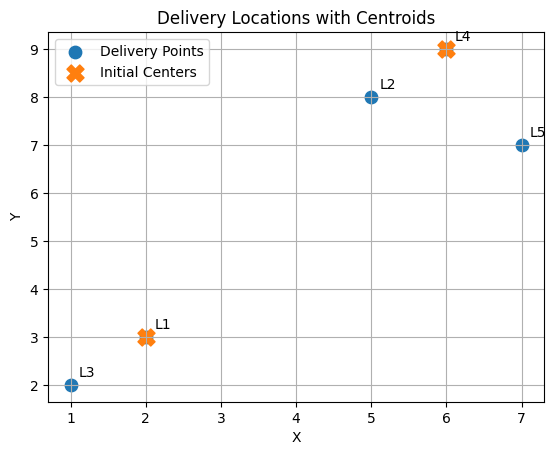

In [7]:
import math
import matplotlib.pyplot as plt

locations = [[2, 3], [5, 8], [1, 2], [6, 9], [7, 7]]
start_centers = [[2, 3], [6, 9]]

def distance_euclid(p1, p2):
    return math.sqrt(sum((a-b)**2 for a,b in zip(p1, p2)))

clusters = []
for loc in locations:
    dist_vals = [distance_euclid(loc, c) for c in start_centers]
    chosen = dist_vals.index(min(dist_vals)) + 1
    clusters.append(chosen)
    print(f'Location {loc} → Cluster {chosen} | Distances = {[round(d,2) for d in dist_vals]}')

print("Final cluster assignments:", clusters)

plt.scatter([x for x,y in locations], [y for x,y in locations], s=80, label="Delivery Points")
plt.scatter([x for x,y in start_centers], [y for x,y in start_centers], s=150, marker="X", label="Initial Centers")
for idx, loc in enumerate(locations):
    plt.annotate(f"L{idx+1}", loc, xytext=(6,6), textcoords="offset points")
plt.title("Delivery Locations with Centroids")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.grid(True)
plt.show()


#Answer:  
#Points are assigned to the nearest centroid using Euclidean distance. Cluster 1 has points near (2,3), Cluster 2 has points near (6,9).

## 2. Euclidean Distance Cluster Assignment


In [8]:
def cluster_assign(points, centers):
    result = []
    for pt in points:
        d = [math.sqrt(sum((a-b)**2 for a,b in zip(pt, c))) for c in centers]
        result.append(d.index(min(d)) + 1)
    return result

cluster_assign(locations, start_centers)


[1, 2, 1, 2, 2]

## 3. Euclidean vs Manhattan Distance

In [9]:
def cluster_assign(points, centers, metric="euclidean"):
    result = []
    for pt in points:
        if metric == "euclidean":
            d = [math.sqrt(sum((a-b)**2 for a,b in zip(pt, c))) for c in centers]
        elif metric == "manhattan":
            d = [sum(abs(a-b) for a,b in zip(pt, c)) for c in centers]
        else:
            raise ValueError("Choose either 'euclidean' or 'manhattan'")
        result.append(d.index(min(d)) + 1)
    return result

print("Euclidean:", cluster_assign(locations, start_centers, "euclidean"))
print("Manhattan:", cluster_assign(locations, start_centers, "manhattan"))

Euclidean: [1, 2, 1, 2, 2]
Manhattan: [1, 2, 1, 2, 2]


## 4. Updating Centroids

In [10]:
def recompute_centers(points, labels, k):
    new_centers = []
    for cid in range(1, k+1):
        group = [p for p,l in zip(points, labels) if l == cid]
        if group:
            new_centers.append([sum(vals)/len(vals) for vals in zip(*group)])
        else:
            new_centers.append(None)
    return new_centers

demo_points = [[1,2],[2,3],[8,9],[9,10],[4,5],[5,4]]
demo_labels = [1,1,2,2,1,1]
print("Updated centers:", recompute_centers(demo_points, demo_labels, 2))


Updated centers: [[3.0, 3.5], [8.5, 9.5]]


## 5. Elbow Method Example

In [ ]:
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

song_features = np.array([
    [55,0.82],[60,0.75],[70,0.78],[80,0.85],[90,0.72],
    [50,0.65],[65,0.68],[75,0.80],[85,0.76],[95,0.70],
    [58,0.79],[68,0.73],[78,0.83],[88,0.74],[98,0.67],
    [52,0.61],[63,0.71],[73,0.77],[83,0.81],[93,0.69]
])

ks = range(1,7)
wcss = []
for k in ks:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(song_features)
    wcss.append(model.inertia_)

print("k values:", list(ks))
print("WCSS:", [round(val,3) for val in wcss])
print("Suggested elbow at k=3")

plt.plot(list(ks), wcss, marker="o")
plt.title("Elbow Method for Songs")
plt.xlabel("Number of clusters (k)")
plt.ylabel("WCSS")
plt.grid(True)
plt.show()
